# Mini-Project 2
## Lecture 4 - Multiprocessing
### Lecture 4 - Milestone 1

Text(0, 0.5, 'Im(c)')

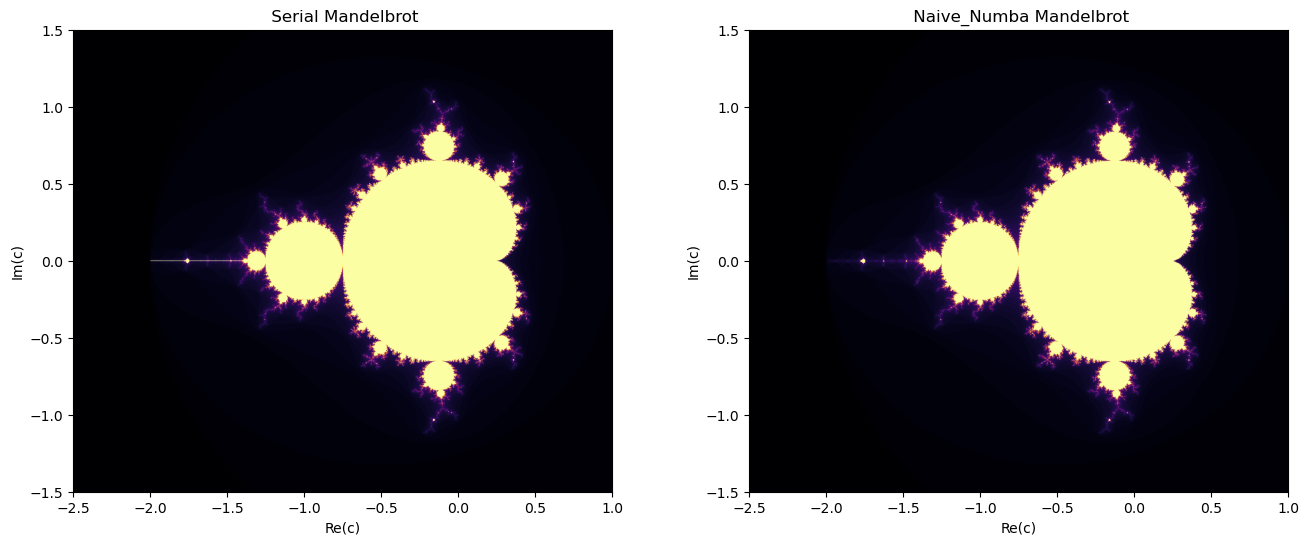

In [1]:
import numpy as np
from numba import njit
from multiprocessing import Pool
import time, os, statistics, matplotlib.pyplot as plt
from pathlib import Path
from mandelbrot_3 import benchmark, compute_mandelbrot_full
from mandelbrot_4 import mandelbrot_serial

# Parameters
iterations = 100
N = 1024
x_dim = (-2.5, 1.0)
y_dim = (-1.5, 1.5)
resolution = (1024, 1024)

#Numba and serial compared
result_full = compute_mandelbrot_full(x_dim=x_dim, y_dim=y_dim, res=resolution, max_iter=iterations)
result_serial = mandelbrot_serial(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=iterations)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
axes[0].imshow(result_serial, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[0].set_title(' Serial Mandelbrot')
axes[0].set_xlabel('Re(c)')
axes[0].set_ylabel('Im(c)')

axes[1].imshow(result_full, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[1].set_title(' Naive_Numba Mandelbrot')
axes[1].set_xlabel('Re(c)')
axes[1].set_ylabel('Im(c)')

The results of the serial mandelbrot implementation (Lecture 4) matches the naive numba mandelbrot implementation (Lecture 3).

### Lecture 4 - Milestone 2

Text(0, 0.5, 'Im(c)')

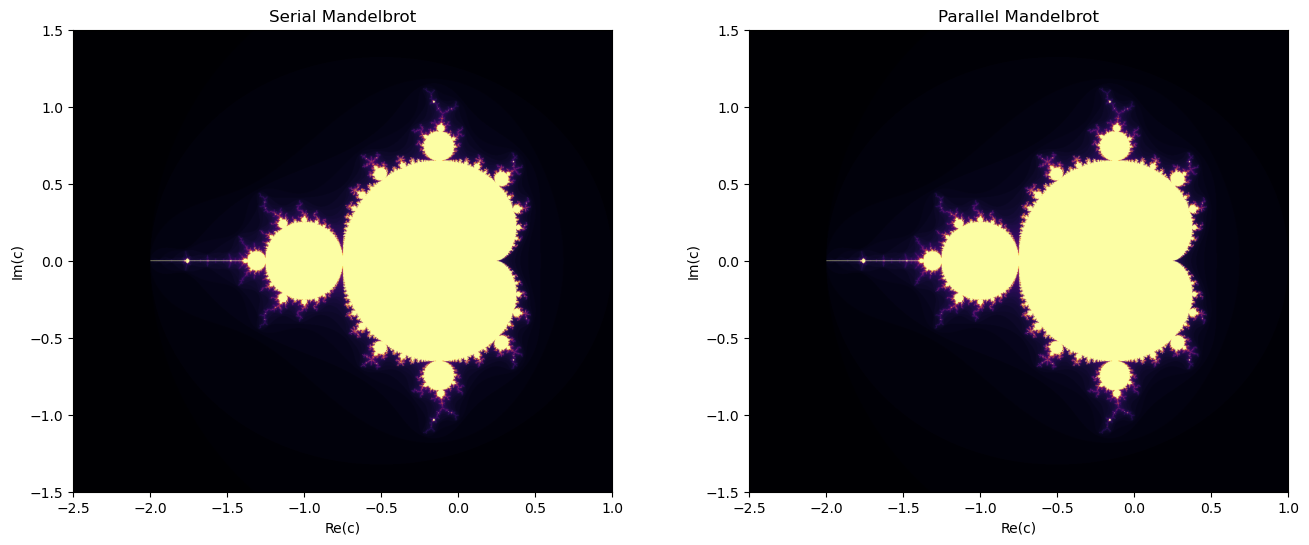

In [2]:
from mandelbrot_4 import mandelbrot_parallel, _worker    

# Parameters
n_workers = 4

# Milestone 2 testing:
result_serial = mandelbrot_serial(N=N, x_dim=x_dim, y_dim=y_dim)
result_parallel = mandelbrot_parallel(N=N, x_dim=x_dim, y_dim=y_dim, num_workers=n_workers)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
axes[0].imshow(result_serial, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[0].set_title('Serial Mandelbrot')
axes[0].set_xlabel('Re(c)')
axes[0].set_ylabel('Im(c)')

axes[1].imshow(result_parallel, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[1].set_title('Parallel Mandelbrot')
axes[1].set_xlabel('Re(c)')
axes[1].set_ylabel('Im(c)')

The results of the parallel mandelbrot implementation (Lecture 4) matches the serial mandelbrot implementation (Lecture 4).

### Lecture 4 - Milestone 3

 1 workers | parallel time: 0.0706s | speedup: 0.85x | efficiency: 0.85
 2 workers | parallel time: 0.0470s | speedup: 1.28x | efficiency: 0.64
 3 workers | parallel time: 0.0527s | speedup: 1.14x | efficiency: 0.38
 4 workers | parallel time: 0.0379s | speedup: 1.59x | efficiency: 0.40
 5 workers | parallel time: 0.0584s | speedup: 1.03x | efficiency: 0.21
 6 workers | parallel time: 0.0309s | speedup: 1.94x | efficiency: 0.32
 7 workers | parallel time: 0.0294s | speedup: 2.05x | efficiency: 0.29
 8 workers | parallel time: 0.0291s | speedup: 2.07x | efficiency: 0.26
speedup_peak=2.07, n_workers_peak=8
 Implied s: 0.41


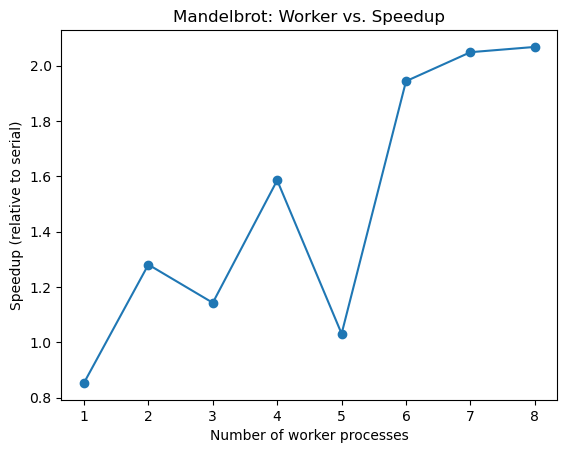

<Figure size 640x480 with 0 Axes>

In [3]:
from monte_carlo_example import plot_worker_speedup

# Parameters
# N, iterations, dimensions are set in L4-M1
n_runs = 3

workers_list = []
speedups = []

# Serial baseline (Numba already warm after M1 warm-up)
times = []
for _ in range(n_runs):
    start_time = time.perf_counter()
    mandelbrot_serial(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=iterations)
    times.append(time.perf_counter() - start_time)
t_serial = statistics.median(times)

for n_workers in range(1, os.cpu_count() + 1):
    chunk_size = max(1, N // n_workers)
    chunks = []
    row = 0
    while row < N:
        row_end = min(row + chunk_size, N) # determine end of the row
        chunks.append((row, row_end, N, x_dim, y_dim, iterations))
        row = row_end

    with Pool(processes=n_workers) as pool:
        pool.map(_worker, chunks)
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            np.vstack(pool.map(_worker, chunks))
            times.append(time.perf_counter() - t0)
    t_parallel = statistics.median(times)
    speedup = t_serial / t_parallel

    # Append workers and speedups for plotting
    workers_list.append(n_workers)
    speedups.append(speedup)

    # print table of workers, speedup and efficiency
    print(f'{n_workers:2d} workers | '
            f'parallel time: {t_parallel:.4f}s | '
            f'speedup: {speedup:.2f}x | '
            f'efficiency: {speedup/n_workers:.2f}')

# get peak for computing the implied s
index_peak = np.argmax(speedups)
speedup_peak = speedups[index_peak]        # optimal speedup
n_workers_peak = workers_list[index_peak]  # optimal number of workers
print(f'{speedup_peak=:.2f}, {n_workers_peak=}')

s_4 = (1/speedup_peak - 1/n_workers_peak) / (1 - 1/n_workers_peak)
print(f' Implied s: {s_4:.2f}')

# Plot worker vs. speedup
plot_worker_speedup(title="Mandelbrot", workers=workers_list, speedup=speedups)
plt.savefig("figures/Mandelbrot_worker_speedup.png")

## Lecture 5 - Multiprocessing + Dask
### Lecture 5 - Milestone 1
Verify result matches serial output for n_chunks 

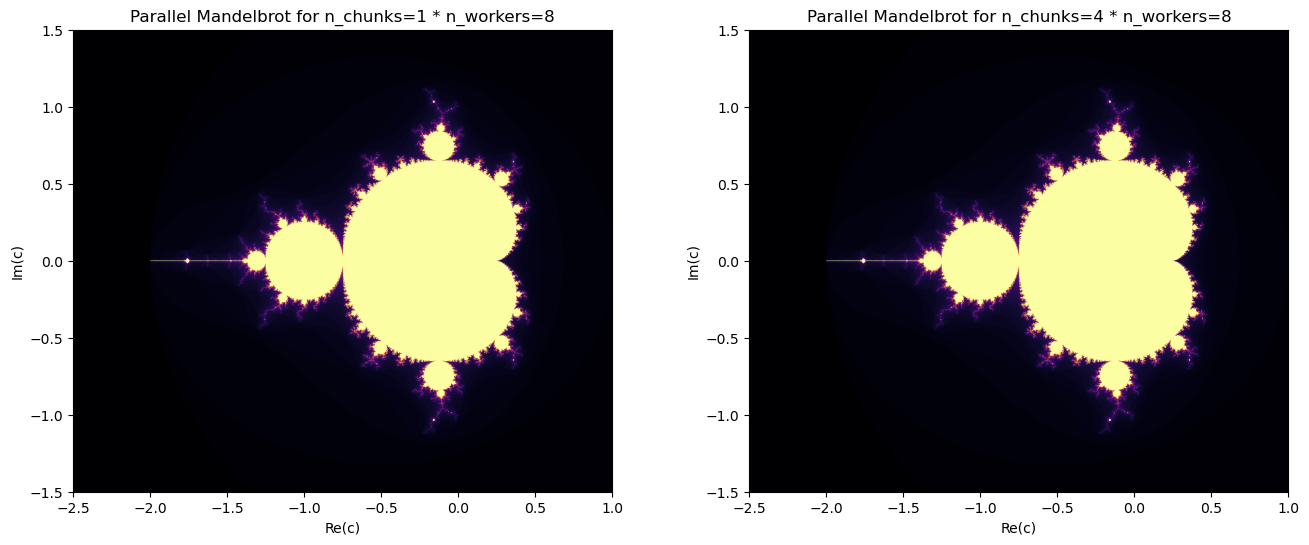

In [4]:
from mandelbrot_5 import mandelbrot_parallel

# Milestone 1 testing:
n_chunks = 4

result_parallel_1nchunk = mandelbrot_parallel(N=N, x_dim=x_dim, y_dim=y_dim, num_workers=n_workers, n_chunks=1*n_workers)
result_parallel_4nchunks = mandelbrot_parallel(N=N, x_dim=x_dim, y_dim=y_dim, num_workers=n_workers, n_chunks=n_chunks*n_workers)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
axes[0].imshow(result_parallel_1nchunk, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[0].set_title(f'Parallel Mandelbrot for n_chunks=1 * {n_workers=}')
axes[0].set_xlabel('Re(c)')
axes[0].set_ylabel('Im(c)')

axes[1].imshow(result_parallel_4nchunks, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[1].set_title(f'Parallel Mandelbrot for {n_chunks=} * {n_workers=}')
axes[1].set_xlabel('Re(c)')
axes[1].set_ylabel('Im(c)')
plt.show()

The parallel mandelbrot for n_chunks=4 and n_workers=8 matches the result of the parallel mandelbrot with n_chunks=1.
It also matches the serial mandelbrot from lecture 4 seen in (L4-M2)

### Lecture 5 - Milestone 2
Record optimal n_chunks and LIF in performance notebook (MP2)

In [5]:
from mandelbrot_5 import mandelbrot_chunk

# Parameters
N = 1024
iterations = 100
n_workers = n_workers_peak
print(f'{n_workers_peak=}')
x_dim = (-2.5, 1.0)
y_dim = (-1.25, 1.25)
n_runs = 3

mandelbrot_chunk(row_start=0, row_end=8, N=8, x_dim=x_dim, y_dim=y_dim, max_iter=iterations) # warm up JIT

# Serial baseline
times = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    mandelbrot_chunk(row_start=0, row_end=N, N=N, x_dim=x_dim, y_dim=y_dim, max_iter=iterations)
    times.append(time.perf_counter() - t0)
t_serial = statistics.median(times)
print(f'Serial: {t_serial:.3f}s')

print(f"{'Num Chunks':>12} | {'Parallel Time':>12} (s) | {'Speedup':>8} (x) | {'LIF':>8} |")

# Chunk-count sweep (M2): one Pool per config
t_parallel_arr = []
n_chunks_arr = []
tiny = [(0, 8, 8, x_dim, y_dim, iterations)]
for mult in [1, 2, 4, 8, 16]:
    n_chunks = mult * n_workers
    n_chunks_arr.append(n_chunks)
    with Pool(processes=n_workers) as pool:
        pool.map(_worker, tiny)         # warm-up: load JIT cache in workers
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            mandelbrot_parallel(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=iterations, num_workers=n_workers, n_chunks=n_chunks, pool=pool)
            times.append(time.perf_counter() - t0)
    t_parallel = statistics.median(times)
    t_parallel_arr.append(t_parallel)   # create array for getting minimum t_parallel
    lif_parallel = n_workers * t_parallel / t_serial - 1

    print(f'{n_chunks:12d} | {t_parallel:17.3f} | {t_serial/t_parallel:12.1f} | {lif_parallel:>8.2f} |')

# Determining optimal n_chunks:
print(f'{t_parallel_arr}')
min_arg = np.argmin(t_parallel_arr)
opt_n_chunks = n_chunks_arr[min_arg]
opt_t_parallel = t_parallel_arr[min_arg]

print(f'Optimal n_chunks is: {opt_n_chunks}, with time: {opt_t_parallel:.3f}s')


n_workers_peak=8
Serial: 0.072s
  Num Chunks | Parallel Time (s) |  Speedup (x) |      LIF |
           8 |             0.029 |          2.5 |     2.19 |
          16 |             0.027 |          2.7 |     2.00 |
          32 |             0.026 |          2.8 |     1.84 |
          64 |             0.022 |          3.3 |     1.40 |
         128 |             0.027 |          2.6 |     2.05 |
[0.028748400043696165, 0.02700809994712472, 0.02560639998409897, 0.021645499975420535, 0.02745140006300062]
Optimal n_chunks is: 64, with time: 0.022s


### Lecture 5 - Milestone 3
Record all results (for all implementations) in performance notebook (MP2)
Speedup table:

In [6]:
# Import mandelbrot naive, numpy, numba and parallel
from mandelbrot_1_2 import compute_mandelbrot_naive, compute_mandelbrot_numpy
from mandelbrot_3 import compute_mandelbrot_full
#from mandelbrot_5 import mandelbrot_parallel

warmup_res = (64, 64)
resolution = (1024, 1024)
N = 1024
iterations = 100

# 1: Speedup table:
print(f'1. Speedup Table:\n',
      f"{'Implementation':>12} | {'Time (s)':>12} | {'Speedup (x)':>12} |")

# Naive Implementation
times = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    compute_mandelbrot_naive(x_dim=x_dim, y_dim=y_dim, res=resolution)
    times.append(time.perf_counter() - t0)
t_naive = statistics.median(times)
speedup_naive = t_naive/t_naive
print(f"{'Naive Python':>15} | {t_naive:12.3f} | {speedup_naive:12.2f} |")

# Numpy baseline
times = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    compute_mandelbrot_numpy(x_dim=x_dim, y_dim=y_dim, res=resolution)
    times.append(time.perf_counter() - t0)
t_numpy = statistics.median(times)
speedup_numpy = t_naive/t_numpy
print(f"{'Numpy':>15} | {t_numpy:12.3f} | {speedup_numpy:12.2f} |")

# Numba baseline
times = []
_ = compute_mandelbrot_full(x_dim=x_dim, y_dim=y_dim, res=warmup_res)  # warmup JIT 
for _ in range(n_runs):
    t0 = time.perf_counter()
    compute_mandelbrot_full(x_dim=x_dim, y_dim=y_dim, res=resolution, max_iter=iterations)
    times.append(time.perf_counter() - t0)
t_numba = statistics.median(times)
speedup_numba = t_naive/t_numba
print(f"{'Numba @njit':>15} | {t_numba:12.3f} | {speedup_numba:12.2f} |")

# Parallel baseline (t_parallel from Milestone 1)
index_t_parallel_peak = np.argmin(t_parallel_arr)
t_parallel = t_parallel_arr[index_t_parallel_peak] # optimal t_parallel
speedup_parallel = t_naive/t_parallel
print(f"{'Parallel (opt)':>15} | {t_parallel:12.3f} | {speedup_parallel:12.2f} |") 

# Back-solve implied:
speedup_parallel_numba = t_numba/t_parallel
print(f'{speedup_parallel_numba=}, {n_workers=}')
s_5 = (1/speedup_parallel_numba - 1/n_workers) / (1 - 1/n_workers)

print('\n2. Speedup vs. core count')
print(f'Implied s (L4): {s_4}')
print(f'Implied s (L5): {s_5}')




1. Speedup Table:
 Implementation |     Time (s) |  Speedup (x) |
   Naive Python |        8.868 |         1.00 |
          Numpy |        1.704 |         5.20 |
    Numba @njit |        0.075 |       118.00 |
 Parallel (opt) |        0.022 |       409.67 |
speedup_parallel_numba=3.471834798464347, n_workers=8

2. Speedup vs. core count
Implied s (L4): 0.4097204538802656
Implied s (L5): 0.1863224434995146


#### 3. Brief Recommendation:
Parallel with n_chunks of 2-4x n_workers results in best speedup at 0.022 s giving a speedup of 411x compared to the naive approach. Compared to numba it is approx 3.4x speedup. 
The Back-solve implied s for L5 is lower than for L4, showing a better balance for the larger number of chunks, while LIF is 1.40 at optimal n_chunks=32  

## Lecture 6 - DASK (Distributed Computing)
### Lecture 6 - Milestone 1


In [7]:
from mandelbrot_5 import mandelbrot_chunk
from mandelbrot_6 import mandelbrot_dask
from mandelbrot_1_2 import compute_mandelbrot_naive
from dask import delayed
from dask.distributed import Client, LocalCluster
import dask, time, statistics

N = 1024
res = (N, N)
max_iter = 100
n_runs = 3

x_dim = (-2.5, 1.0)
y_dim = (-1.25, 1.25)
cluster = LocalCluster(n_workers=8, threads_per_worker=1)
client = Client(cluster)
client.run(lambda: mandelbrot_chunk(row_start=0, row_end=8, N=8, x_dim=x_dim, y_dim=y_dim, max_iter=max_iter))

times = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    result_dask = mandelbrot_dask(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=max_iter)
    times.append(time.perf_counter() - t0)
    time_dask = statistics.median(times)
print(f"Dask local (n_chunks=32): {time_dask:.3f} s")
client.close(); cluster.close()

times = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    compute_mandelbrot_naive(x_dim=x_dim, y_dim=y_dim, res=res)
    times.append(time.perf_counter() - t0)
    time_naive = statistics.median(times)
print(f'Naive: {time_naive} s')
print(f"Speedup: {time_naive/time_dask:.3f} x")

#Checking whether serial and dask arrays are equal
result_serial = mandelbrot_serial(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=max_iter)
print(np.array_equal(result_serial, result_dask))



Dask local (n_chunks=32): 0.193 s
Naive: 8.918712099897675 s
Speedup: 46.225 x
True


### Lecture 6 - Milestone 2
Find the optimal chunk count for Dask local on your machine.
Record n chunks optimal and LIF min in performance notebook (MP2)

c:\Users\mathi\miniforge3\envs\nsc2026\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 58798 instead
  warnings.warn(


Chunks:   1 | Time: 0.15s | Speedup: 1.00x | LIF: 0.00
Chunks:   2 | Time: 0.19s | Speedup: 0.82x | LIF: 1.45
Chunks:   4 | Time: 0.20s | Speedup: 0.75x | LIF: 4.30
Chunks:   8 | Time: 0.10s | Speedup: 1.50x | LIF: 4.34
Chunks:  16 | Time: 0.23s | Speedup: 0.65x | LIF: 23.74
Chunks:  32 | Time: 0.28s | Speedup: 0.54x | LIF: 58.39
Chunks:  64 | Time: 0.53s | Speedup: 0.29x | LIF: 220.27
Chunks: 128 | Time: 1.56s | Speedup: 0.10x | LIF: 1311.14


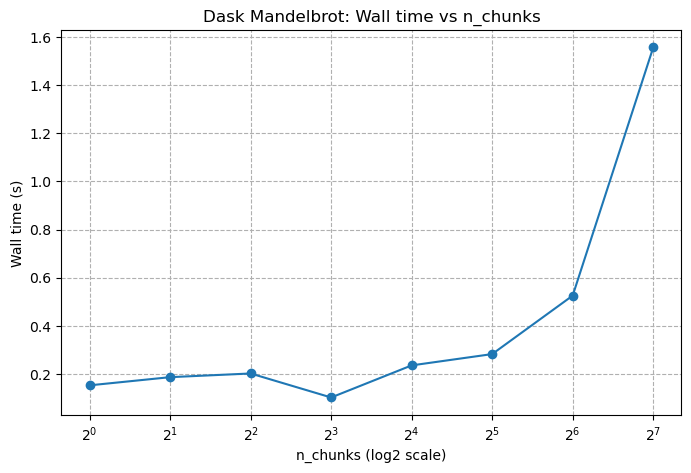

Optimal n_chunks: 8, t_min: 0.10s, LIF_min: 4.34


In [14]:
from dask import delayed
from dask.distributed import Client, LocalCluster
import dask, time, statistics
import numpy as np
import matplotlib.pyplot as plt
from mandelbrot_5 import mandelbrot_chunk
from mandelbrot_6 import mandelbrot_dask

# Sweep over n_chunks
N = 1024 
n_runs = 3
x_dim = (-2.0, 1.0)
y_dim = (-1.5, 1.5)
max_iter = 100
chunk_values = [1, 2, 4, 8, 16, 32, 64, 128]  # n_chunks to sweep over

cluster = LocalCluster(n_workers=8, threads_per_worker=1)
client = Client(cluster)
client.run(lambda: mandelbrot_chunk(row_start=0, row_end=8, N=8, x_dim=x_dim, y_dim=y_dim, max_iter=max_iter)) # warmup clients

results = []

for n_chunks in chunk_values:
    run_times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        mandelbrot_dask(N, x_dim, y_dim, max_iter, n_chunks=n_chunks)
        run_times.append(time.perf_counter() - start)
    median_time = statistics.median(run_times)
    if n_chunks == 1:
        T1 = median_time  # baseline
        speedup = 1.0
        LIF = 0.0
    else:
        speedup = T1 / median_time
        LIF = n_chunks * median_time / T1 - 1
    results.append((n_chunks, median_time, speedup, LIF))
    print(f"Chunks: {n_chunks:3d} | Time: {median_time:.2f}s | Speedup: {speedup:.2f}x | LIF: {LIF:.2f}")
client.close(); cluster.close()

# Convert results to arrays for plotting
results_array = np.array(results)
n_chunks_arr = results_array[:,0]
times_arr = results_array[:,1]
speedup_arr = results_array[:,2]
LIF_arr = results_array[:,3]

# Plot wall time vs n_chunks
plt.figure(figsize=(8,5))
plt.plot(n_chunks_arr, times_arr, marker='o')
plt.xscale('log', base=2)
plt.xlabel("n_chunks (log2 scale)")
plt.ylabel("Wall time (s)")
plt.title("Dask Mandelbrot: Wall time vs n_chunks")
plt.grid(True, which='both', ls='--')
plt.savefig("figures/dask_chunk_sweep.png", dpi=150)
plt.show()

# Find optimal chunk count
optimal_idx = np.argmin(times_arr)
n_optimal = int(n_chunks_arr[optimal_idx])
t_min_dask = times_arr[optimal_idx]
LIF_min = LIF_arr[optimal_idx]

print(f"Optimal n_chunks: {n_optimal}, t_min: {t_min_dask:.2f}s, LIF_min: {LIF_min:.2f}")

### Lecture 6 - Milestone 3
Collect all timings and compare every implementation built so far.
Add your Dask local result to the Performance Tracker in Moodle.

In [15]:
from mandelbrot_1_2 import benchmark, compute_mandelbrot_naive, compute_mandelbrot_numpy
from mandelbrot_3 import compute_mandelbrot_full
from mandelbrot_5 import mandelbrot_chunk, mandelbrot_parallel
from mandelbrot_6 import mandelbrot_dask
from dask import delayed
from dask.distributed import Client, LocalCluster
import dask, time, statistics
import numpy as np
from numba import njit
from multiprocessing import Pool
from pathlib import Path

# Parameters
warmup = 64
N = 1024 
n_runs = 3
x_dim = (-2.0, 1.0)
y_dim = (-1.5, 1.5)
iterations = 100
n_workers = 8
chunk_values = [1, 2, 4, 8, 16, 32, 64, 128]  # sweep over n_chunks
resolution_warmup = (warmup, warmup)
resolution = (N, N)

# 1: Speedup table:
print(f'Speedup Table:\n',
      f"{'Implementation':>12} | {'Time (s)':>12} | {'Speedup (x)':>12} |")

# Naive Implementation
times = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    compute_mandelbrot_naive(x_dim=x_dim, y_dim=y_dim, res=resolution)
    times.append(time.perf_counter() - t0)
t_naive = statistics.median(times)
speedup_naive = t_naive/t_naive
print(f"{'Naive Python':>15} | {t_naive:12.3f} | {speedup_naive:12.2f} |")

# Numpy Implementation
times = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    compute_mandelbrot_numpy(x_dim=x_dim, y_dim=y_dim, res=resolution)
    times.append(time.perf_counter() - t0)
t_numpy = statistics.median(times)
speedup_numpy = t_naive/t_numpy
print(f"{'Numpy':>15} | {t_numpy:12.3f} | {speedup_numpy:12.2f} |")

# Numba Implementation
times = []
_ = compute_mandelbrot_full(x_dim=x_dim, y_dim=y_dim, res=resolution_warmup)  # warmup JIT 
for _ in range(n_runs):
    t0 = time.perf_counter()
    compute_mandelbrot_full(x_dim=x_dim, y_dim=y_dim, res=resolution, max_iter=iterations)
    times.append(time.perf_counter() - t0)
t_numba = statistics.median(times)
speedup_numba = t_naive/t_numba
print(f"{'Numba @njit':>15} | {t_numba:12.3f} | {speedup_numba:12.2f} |")

# Parallel Implementation (t_parallel from L5-M2)
index_t_parallel_peak = np.argmin(t_parallel_arr)
t_parallel = t_parallel_arr[index_t_parallel_peak] # optimal t_parallel
speedup_parallel = t_naive/t_parallel
print(f"{'Parallel (opt)':>15} | {t_parallel:12.3f} | {speedup_parallel:12.2f} |")

# Benchmark for Dask implementation (Dask from L6-M2)
speedup_dask = t_naive/t_min_dask
print(f"{'Dask (opt)':>15} | {t_min_dask:12.3f} | {speedup_dask:12.2f} |")

Speedup Table:
 Implementation |     Time (s) |  Speedup (x) |
   Naive Python |       12.213 |         1.00 |
          Numpy |        2.753 |         4.44 |
    Numba @njit |        0.085 |       143.16 |
 Parallel (opt) |        0.022 |       564.25 |
     Dask (opt) |        0.101 |       120.42 |


Parallel and dask implementation are only computed for the optimal n_chunk which is 64 for parallel (n_chunk=8 * n_workers=8) and 8 for dask.

## Lecture 7 - DASK on Strato Cluster

#### Lecture 7 - Experiment 1: Chunk size sweep
As it was not possible to create new instances or snapshots, it was not possible to test on a VM.
Instead I tried for LocalCluster, to firstly find the optimal number of chunks (in experiment 1).
Afterwards I used this optimal number of chunks and swept number of workers (in experiment 2), but for LocalCluster and not for multiple VMs.

Numba serial time (res=4096): 1.24s
Chunks:   1 | Time: 3.94s | Speedup: 0.31x
Chunks:   2 | Time: 1.04s | Speedup: 1.19x
Chunks:   4 | Time: 0.97s | Speedup: 1.27x
Chunks:   8 | Time: 0.83s | Speedup: 1.49x
Chunks:  16 | Time: 0.85s | Speedup: 1.45x
Chunks:  32 | Time: 0.90s | Speedup: 1.38x
Chunks:  64 | Time: 1.10s | Speedup: 1.12x
Chunks: 128 | Time: 1.13s | Speedup: 1.09x


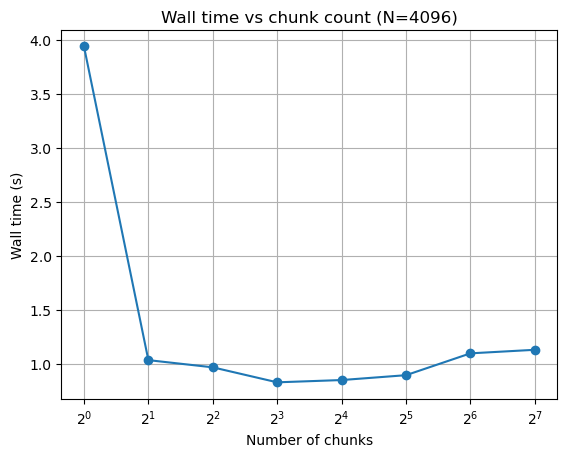

Optimal n_chunks: 8, time: 0.83s


In [24]:
from dask.distributed import Client, LocalCluster
import time, statistics
import numpy as np
import matplotlib.pyplot as plt
from mandelbrot_3 import compute_mandelbrot_full
from mandelbrot_7 import mandelbrot_dask

# Parameters
N = 4096
res = (N, N)
iterations = 100
n_runs = 3
x_dim = (-2.5, 1.0)
y_dim = (-1.25, 1.25)
chunk_values = [1, 2, 4, 8, 16, 32, 64, 128]

# Serial numba baseline
times = []
_ = compute_mandelbrot_full(x_dim=x_dim, y_dim=y_dim, res=(64,64))  # warmup
for _ in range(n_runs):
    t0 = time.perf_counter()
    compute_mandelbrot_full(x_dim=x_dim, y_dim=y_dim, res=res, max_iter=iterations)
    times.append(time.perf_counter() - t0)

t_numba_serial = statistics.median(times)
print(f"Numba serial time (res=4096): {t_numba_serial:.2f}s")

# Dask setup (should be using the head node)
cluster = LocalCluster(n_workers=4, threads_per_worker=1, dashboard_address=None)
client = Client(cluster)

# Chunk sweep
results = []

for n_chunks in chunk_values:
    run_times = []

    for _ in range(n_runs):
        start = time.perf_counter()
        mandelbrot_dask(N, x_dim, y_dim, iterations, n_chunks=n_chunks)
        run_times.append(time.perf_counter() - start)

    median_time = statistics.median(run_times)
    speedup = t_numba_serial / median_time

    results.append((n_chunks, median_time, speedup))
    print(f"Chunks: {n_chunks:3d} | Time: {median_time:.2f}s | Speedup: {speedup:.2f}x")

client.close()
cluster.close()

# Plot
results_array = np.array(results)
n_chunks_arr = results_array[:,0]
times_arr = results_array[:,1]

plt.figure()
plt.plot(n_chunks_arr, times_arr, marker='o')
plt.xscale('log', base=2)
plt.xlabel("Number of chunks")
plt.ylabel("Wall time (s)")
plt.title("Wall time vs chunk count (N=4096)")
plt.grid(True)
plt.show()

# Best chunk size
optimal_idx = np.argmin(times_arr)
n_optimal = int(n_chunks_arr[optimal_idx])
t_min = times_arr[optimal_idx]

print(f"Optimal n_chunks: {n_optimal}, time: {t_min:.2f}s")

#### Lecture 7 - Experiment 2: Worker Scaling

As I cannot create anymore snapshots or instances I cannot perform this experiment as I can only access 1 worker (i.e the head node)
I have instead listed below how I would test for multiple workers at a constant optimal n_chunk.


Workers: 1
Time: 1.50s | Speedup: 0.82x

Workers: 2
Time: 1.12s | Speedup: 1.10x

Workers: 3
Time: 0.96s | Speedup: 1.29x

Workers: 4
Time: 1.40s | Speedup: 0.88x

Workers: 5
Time: 1.02s | Speedup: 1.21x

Workers: 6
Time: 0.97s | Speedup: 1.27x

Workers: 7
Time: 0.95s | Speedup: 1.31x

Workers: 8
Time: 5.58s | Speedup: 0.22x


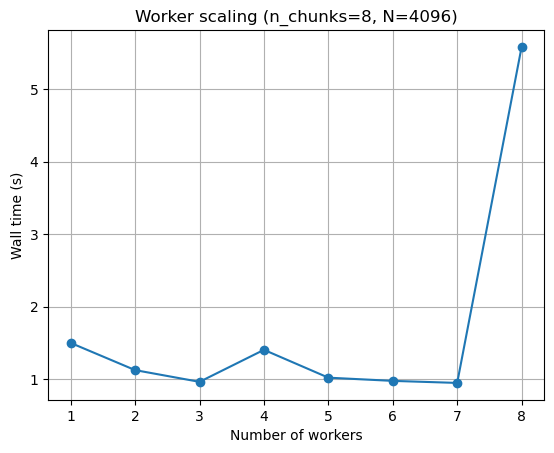

In [ ]:
from dask.distributed import Client, LocalCluster
import time, statistics
import numpy as np
import matplotlib.pyplot as plt
from mandelbrot_7 import mandelbrot_dask

# Reuse from Experiment 1
N = 4096
iterations = 100
n_runs = 3
x_dim = (-2.5, 1.0)
y_dim = (-1.25, 1.25)

# optimal chunk from Experiment 1
n_optimal = 8

# Worker counts to test
worker_counts = list(range(1, 9))
results = []

for n_workers in worker_counts:
    print(f"\nWorkers: {n_workers}")

    cluster = LocalCluster(n_workers=n_workers, threads_per_worker=1, dashboard_address=None)
    client = Client(cluster)

    run_times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        mandelbrot_dask(N, x_dim, y_dim, iterations, n_chunks=n_optimal)
        run_times.append(time.perf_counter() - start)

    median_time = statistics.median(run_times)
    speedup = t_numba_serial / median_time

    results.append((n_workers, median_time, speedup))
    print(f"Time: {median_time:.2f}s | Speedup: {speedup:.2f}x")

    client.close()
    cluster.close()

# Plot wall time
results_array = np.array(results)
workers_arr = results_array[:,0]
times_arr = results_array[:,1]
speedup_arr = results_array[:,2]

plt.figure()
plt.plot(workers_arr, times_arr, marker='o')
plt.xlabel("Number of workers")
plt.ylabel("Wall time (s)")
plt.title(f"Worker scaling (n_chunks={n_optimal}, N=4096)")
plt.grid(True)
plt.show()